# **VOYAGE ANALYTICS — FLIGHT PRICE REGRESSION MODEL**
### Goal    : Predict flight price using flights.csv
### Features: distance, flightType, agency, month, day_of_week
### Target  : price

## **IMPORTS**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import os
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

print("-> All libraries imported successfully")

-> All libraries imported successfully


## **LOAD DATA**

In [2]:
# Path relative to notebooks folder
DATA_PATH = '../data/flights.csv'

flights = pd.read_csv(DATA_PATH)

print("=" * 50)
print("FLIGHTS DATASET LOADED")
print("=" * 50)
print(f"Shape          : {flights.shape}")
print(f"Rows           : {flights.shape[0]:,}")
print(f"Columns        : {flights.shape[1]}")
print(f"\nColumn Names   : {flights.columns.tolist()}")
print(f"\nData Types:\n{flights.dtypes}")
print(f"\nFirst 5 Rows:")
flights.head()

FLIGHTS DATASET LOADED
Shape          : (271888, 10)
Rows           : 271,888
Columns        : 10

Column Names   : ['travelCode', 'userCode', 'from', 'to', 'flightType', 'price', 'time', 'distance', 'agency', 'date']

Data Types:
travelCode      int64
userCode        int64
from           object
to             object
flightType     object
price         float64
time          float64
distance      float64
agency         object
date           object
dtype: object

First 5 Rows:


,travelCode,userCode,from,to,flightType,price,time,distance,agency,date
0,0,0,Recife (PE),Florianopolis (SC),firstClass,1434.38,1.76,676.53,FlyingDrops,09/26/2019
1,0,0,Florianopolis (SC),Recife (PE),firstClass,1292.29,1.76,676.53,FlyingDrops,09/30/2019
2,1,0,Brasilia (DF),Florianopolis (SC),firstClass,1487.52,1.66,637.56,CloudFy,10/03/2019
3,1,0,Florianopolis (SC),Brasilia (DF),firstClass,1127.36,1.66,637.56,CloudFy,10/04/2019
4,2,0,Aracaju (SE),Salvador (BH),firstClass,1684.05,2.16,830.86,CloudFy,10/10/2019


## **QUICK DATA VALIDATION**

In [3]:
print("MISSING VALUES:")
print(flights.isnull().sum())

print(f"\nDUPLICATE ROWS: {flights.duplicated().sum()}")

print(f"\nTARGET VARIABLE (price) STATS:")
print(flights['price'].describe())

print(f"\nFLIGHT TYPE DISTRIBUTION:")
print(flights['flightType'].value_counts())

print(f"\nAGENCY DISTRIBUTION:")
print(flights['agency'].value_counts())

MISSING VALUES:
travelCode    0
userCode      0
from          0
to            0
flightType    0
price         0
time          0
distance      0
agency        0
date          0
dtype: int64

DUPLICATE ROWS: 0

TARGET VARIABLE (price) STATS:
count    271888.00000
mean        957.37503
std         362.31189
min         301.51000
25%         672.66000
50%         904.00000
75%        1222.24000
max        1754.17000
Name: price, dtype: float64

FLIGHT TYPE DISTRIBUTION:
flightType
firstClass    116418
premium        78004
economic       77466
Name: count, dtype: int64

AGENCY DISTRIBUTION:
agency
Rainbow        116752
CloudFy        116378
FlyingDrops     38758
Name: count, dtype: int64


## **FEATURE ENGINEERING**

In [4]:
# EDA Insights Applied:
# Drop 'time' → perfectly correlated with distance (r=1.000)
# Extract month from date → seasonal patterns found
# Drop travelCode, userCode → just IDs 
# Drop from, to → too many unique route combinations
# ============================================================

def engineer_features(df):
    """Feature engineering pipeline based on EDA insights."""
    
    df = df.copy()
    
    # Parse date
    df['date'] = pd.to_datetime(df['date'])
    
    # Extract time features
    df['month']       = df['date'].dt.month
    df['day_of_week'] = df['date'].dt.dayofweek
    
    # Drop columns
    cols_to_drop = [
        'travelCode',   # ID only
        'userCode',     # ID only
        'date',         # replaced by month + day_of_week
        'time',         # perfectly correlated with distance (r=1.000)
        'from',         # too many categories
        'to',           # too many categories
    ]
    df = df.drop(columns=cols_to_drop, errors='ignore')
    
    return df


flights_featured = engineer_features(flights)

print("AFTER FEATURE ENGINEERING:")
print(f"Shape   : {flights_featured.shape}")
print(f"Columns : {flights_featured.columns.tolist()}")
print(f"\nSample:")
flights_featured.head()

AFTER FEATURE ENGINEERING:
Shape   : (271888, 6)
Columns : ['flightType', 'price', 'distance', 'agency', 'month', 'day_of_week']

Sample:


,flightType,price,distance,agency,month,day_of_week
0,firstClass,1434.38,676.53,FlyingDrops,9,3
1,firstClass,1292.29,676.53,FlyingDrops,9,0
2,firstClass,1487.52,637.56,CloudFy,10,3
3,firstClass,1127.36,637.56,CloudFy,10,4
4,firstClass,1684.05,830.86,CloudFy,10,3


## **ENCODE CATEGORICAL VARIABLES**

In [5]:
def encode_features(df):
    """
    Encode categorical columns.
    
    flightType -> Ordinal (economic=0, premium=1, firstClass=2)
                 Natural price ordering confirmed in EDA
    agency     -> One-Hot (no natural order between agencies)
    """
    df = df.copy()
    
    # Ordinal encoding for flightType
    flight_type_map = {
        'economic': 0, 'premium': 1, 'firstClass': 2
    }
    df['flightType_encoded'] = df['flightType'].map(flight_type_map)
    
    # One-hot encoding for agency
    agency_dummies = pd.get_dummies(
        df['agency'], prefix='agency', drop_first=False   # keep all 3 for interpretability
    )
    df = pd.concat([df, agency_dummies], axis=1)
    
    # Drop original categorical columns
    df = df.drop(columns=['flightType', 'agency'])
    
    return df


flights_encoded = encode_features(flights_featured)

print("AFTER ENCODING:")
print(f"Shape   : {flights_encoded.shape}")
print(f"Columns : {flights_encoded.columns.tolist()}")
print(f"\nSample:")
flights_encoded.head()

AFTER ENCODING:
Shape   : (271888, 8)
Columns : ['price', 'distance', 'month', 'day_of_week', 'flightType_encoded', 'agency_CloudFy', 'agency_FlyingDrops', 'agency_Rainbow']

Sample:


,price,distance,month,day_of_week,flightType_encoded,agency_CloudFy,agency_FlyingDrops,agency_Rainbow
0,1434.38,676.53,9,3,2,False,True,False
1,1292.29,676.53,9,0,2,False,True,False
2,1487.52,637.56,10,3,2,True,False,False
3,1127.36,637.56,10,4,2,True,False,False
4,1684.05,830.86,10,3,2,True,False,False


## **PREPARE FEATURES (X) AND TARGET (y)**

In [6]:
TARGET = 'price'

X = flights_encoded.drop(columns=[TARGET])
y = flights_encoded[TARGET]

print(f"Feature Matrix X : {X.shape}")
print(f"Target Vector  y : {y.shape}")
print(f"\nFeature Columns  : {X.columns.tolist()}")
print(f"\nTarget Stats:")
print(y.describe())
print(f"\nMissing in X : {X.isnull().sum().sum()}")
print(f"Missing in y : {y.isnull().sum()}")

Feature Matrix X : (271888, 7)
Target Vector  y : (271888,)

Feature Columns  : ['distance', 'month', 'day_of_week', 'flightType_encoded', 'agency_CloudFy', 'agency_FlyingDrops', 'agency_Rainbow']

Target Stats:
count    271888.00000
mean        957.37503
std         362.31189
min         301.51000
25%         672.66000
50%         904.00000
75%        1222.24000
max        1754.17000
Name: price, dtype: float64

Missing in X : 0
Missing in y : 0


## **TRAIN-TEST SPLIT**

In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,      # 80% train / 20% test
    random_state=42     # reproducibility
)

print(f"Total Samples  : {len(X):,}")
print(f"Training Set   : {len(X_train):,} ({len(X_train)/len(X)*100:.0f}%)")
print(f"Test Set       : {len(X_test):,}  ({len(X_test)/len(X)*100:.0f}%)")

# Scale features (needed for Linear Regression)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print(f"\n-> Train-Test Split Complete")
print(f"-> StandardScaler Fitted")

Total Samples  : 271,888
Training Set   : 217,510 (80%)
Test Set       : 54,378  (20%)

-> Train-Test Split Complete
-> StandardScaler Fitted


## **TRAIN AND COMPARE MODELS**

In [8]:
def evaluate_model(name, model, X_tr, X_te, y_tr, y_te):
    """Train model and compute evaluation metrics."""
    
    model.fit(X_tr, y_tr)
    
    y_pred_train = model.predict(X_tr)
    y_pred_test  = model.predict(X_te)
    
    metrics = {
        'Model'    : name,
        'Train R²' : round(r2_score(y_tr, y_pred_train), 4),
        'Test R²'  : round(r2_score(y_te, y_pred_test),  4),
        'MAE'      : round(mean_absolute_error(y_te, y_pred_test), 2),
        'RMSE'     : round(np.sqrt(mean_squared_error(y_te, y_pred_test)), 2),
        'MAPE %'   : round(np.mean(np.abs((y_te - y_pred_test) / y_te)) * 100, 2)
    }
    
    return metrics, model


# Define models
models_to_try = {
    'Linear Regression' : LinearRegression(),
    
    'Random Forest'     : RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1),
    
    'Gradient Boosting' : GradientBoostingRegressor(n_estimators=100, learning_rate=0.1, max_depth=4, random_state=42)
}

# Train all models
results       = []
trained_models = {}

print("TRAINING MODELS...")
print("=" * 60)

for name, model in models_to_try.items():
    print(f"  Training {name}...", end='')
    
    # Linear Regression uses scaled data
    # Tree models use raw data
    if name == 'Linear Regression':
        metrics, trained = evaluate_model(
            name, model,
            X_train_scaled, X_test_scaled,
            y_train, y_test
        )
    else:
        metrics, trained = evaluate_model(
            name, model,
            X_train, X_test,
            y_train, y_test
        )
    
    results.append(metrics)
    trained_models[name] = trained
    print(f" ->  Test R²: {metrics['Test R²']} | MAE: ${metrics['MAE']}")

# Results table
print("\n")
results_df = pd.DataFrame(results).sort_values('Test R²', ascending=False)
print("=" * 70)
print("MODEL COMPARISON RESULTS")
print("=" * 70)
print(results_df.to_string(index=False))

TRAINING MODELS...
  Training Linear Regression... ->  Test R²: 0.7703 | MAE: $134.58
  Training Random Forest... ->  Test R²: 0.9067 | MAE: $61.8
  Training Gradient Boosting... ->  Test R²: 0.8819 | MAE: $86.34


MODEL COMPARISON RESULTS
            Model  Train R²  Test R²    MAE   RMSE  MAPE %
    Random Forest    0.9167   0.9067  61.80 110.90    7.08
Gradient Boosting    0.8830   0.8819  86.34 124.73    9.81
Linear Regression    0.7713   0.7703 134.58 173.98   16.59


## **Hyperparameter Tuning (Random Forest)**

In [9]:
print("Tuning Random Forest...")

param_grid = {
    'n_estimators'    : [100, 200],
    'max_depth'       : [None, 20, 30],
    'min_samples_split': [2, 5],
    'min_samples_leaf' : [1, 2],
}

grid_search = GridSearchCV(
    estimator = RandomForestRegressor(random_state=42, n_jobs=-1),
    param_grid = param_grid,
    cv         = 5,
    scoring    = 'r2',
    n_jobs     = -1,
    verbose    = 1
)

grid_search.fit(X_train, y_train)

print(f"\n-> Best Parameters : {grid_search.best_params_}")
print(f"-> Best CV R²      : {grid_search.best_score_:.4f}")

# Evaluate best model
best_model  = grid_search.best_estimator_
y_pred_best = best_model.predict(X_test)

print(f"\nBEST MODEL PERFORMANCE ON TEST SET:")
print(f"  R²   : {r2_score(y_test, y_pred_best):.4f}")
print(f"  MAE  : ${mean_absolute_error(y_test, y_pred_best):.2f}")
print(f"  RMSE : ${np.sqrt(mean_squared_error(y_test, y_pred_best)):.2f}")

Tuning Random Forest...
Fitting 5 folds for each of 24 candidates, totalling 120 fits

-> Best Parameters : {'max_depth': 20, 'min_samples_leaf': 2, 'min_samples_split': 5, 'n_estimators': 200}
-> Best CV R²      : 0.9071

BEST MODEL PERFORMANCE ON TEST SET:
  R²   : 0.9069
  MAE  : $61.78
  RMSE : $110.75


## **FEATURE IMPORTANCE**

FEATURE IMPORTANCE RANKING:
           Feature  Importance
          distance    0.545153
flightType_encoded    0.405840
       day_of_week    0.037674
             month    0.005785
    agency_CloudFy    0.002177
    agency_Rainbow    0.001889
agency_FlyingDrops    0.001483


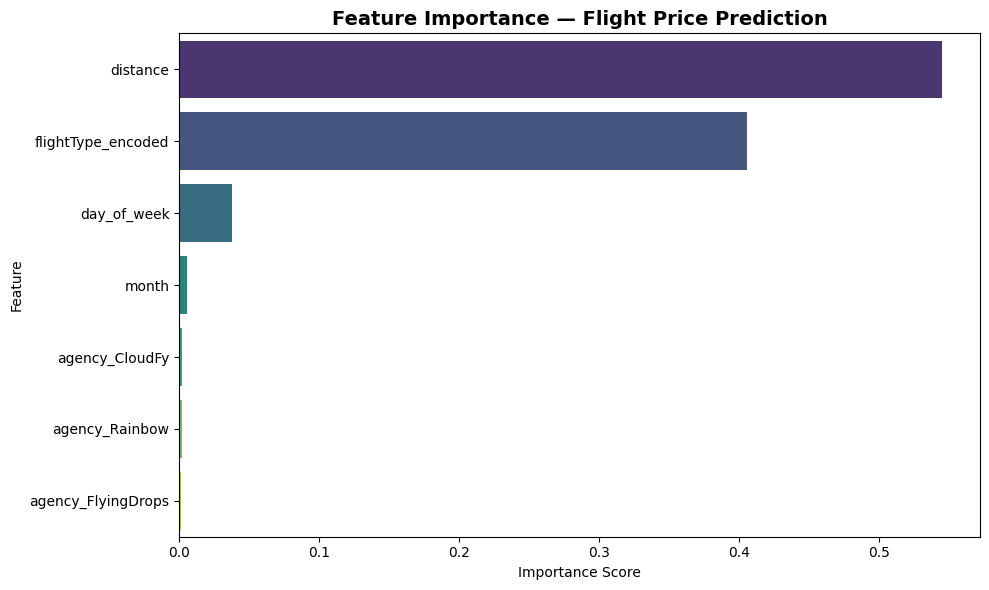

-> Feature importance plot saved to models/plots/


In [10]:
feature_importance = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': best_model.feature_importances_
}).sort_values('Importance', ascending=False)

print("FEATURE IMPORTANCE RANKING:")
print(feature_importance.to_string(index=False))

# Plot
plt.figure(figsize=(10, 6))
sns.barplot(
    data=feature_importance,
    x='Importance',
    y='Feature',
    palette='viridis'
)
plt.title('Feature Importance — Flight Price Prediction', 
          fontsize=14, fontweight='bold')
plt.xlabel('Importance Score')
plt.ylabel('Feature')
plt.tight_layout()
plt.savefig('../models/plots/feature_importance.png', dpi=150)
plt.show()
print("-> Feature importance plot saved to models/plots/")

## **SAVE MODEL ARTIFACTS**

In [11]:
import os
import joblib

NOTEBOOK_DIR = os.getcwd()          # currently in notebooks/
PROJECT_ROOT = os.path.dirname(NOTEBOOK_DIR)   # go up to voyage-analytics/
MODELS_DIR   = os.path.join(PROJECT_ROOT, 'models')

print(f"Project Root : {PROJECT_ROOT}")
print(f"Models Dir   : {MODELS_DIR}")

os.makedirs(MODELS_DIR, exist_ok=True)

# Save best model
joblib.dump(best_model, os.path.join(MODELS_DIR, 'flight_price_model.pkl'))

# Save scaler
joblib.dump(scaler, os.path.join(MODELS_DIR, 'scaler.pkl'))

# Save feature column names
feature_columns = X_train.columns.tolist()
joblib.dump(feature_columns, os.path.join(MODELS_DIR, 'feature_columns.pkl'))

print("-> ARTIFACTS SAVED TO:")
print(f"   -> {os.path.join(MODELS_DIR, 'flight_price_model.pkl')}")
print(f"   -> {os.path.join(MODELS_DIR, 'scaler.pkl')}")
print(f"   -> {os.path.join(MODELS_DIR, 'feature_columns.pkl')}")

# Verify by loading back
loaded_model = joblib.load(os.path.join(MODELS_DIR, 'flight_price_model.pkl'))
print(f"\n-> Verification: Model loaded successfully")
print(f"   Type: {type(loaded_model)}")
test_preds   = loaded_model.predict(X_test[:3])
print(f"\n-> MODEL VERIFICATION — First 3 Predictions:")
for pred, actual in zip(test_preds, y_test[:3]):
    print(f"   Predicted: ${pred:,.2f}  |  Actual: ${actual:,.2f}  |  Diff: ${abs(pred-actual):,.2f}")

Project Root : c:\Users\AKSHAY SOM\Desktop\voyage-analytics
Models Dir   : c:\Users\AKSHAY SOM\Desktop\voyage-analytics\models
-> ARTIFACTS SAVED TO:
   -> c:\Users\AKSHAY SOM\Desktop\voyage-analytics\models\flight_price_model.pkl
   -> c:\Users\AKSHAY SOM\Desktop\voyage-analytics\models\scaler.pkl
   -> c:\Users\AKSHAY SOM\Desktop\voyage-analytics\models\feature_columns.pkl

-> Verification: Model loaded successfully
   Type: <class 'sklearn.ensemble._forest.RandomForestRegressor'>

-> MODEL VERIFICATION — First 3 Predictions:
   Predicted: $481.42  |  Actual: $481.42  |  Diff: $0.00
   Predicted: $1,141.87  |  Actual: $1,124.11  |  Diff: $17.76
   Predicted: $1,167.86  |  Actual: $1,174.97  |  Diff: $7.11
